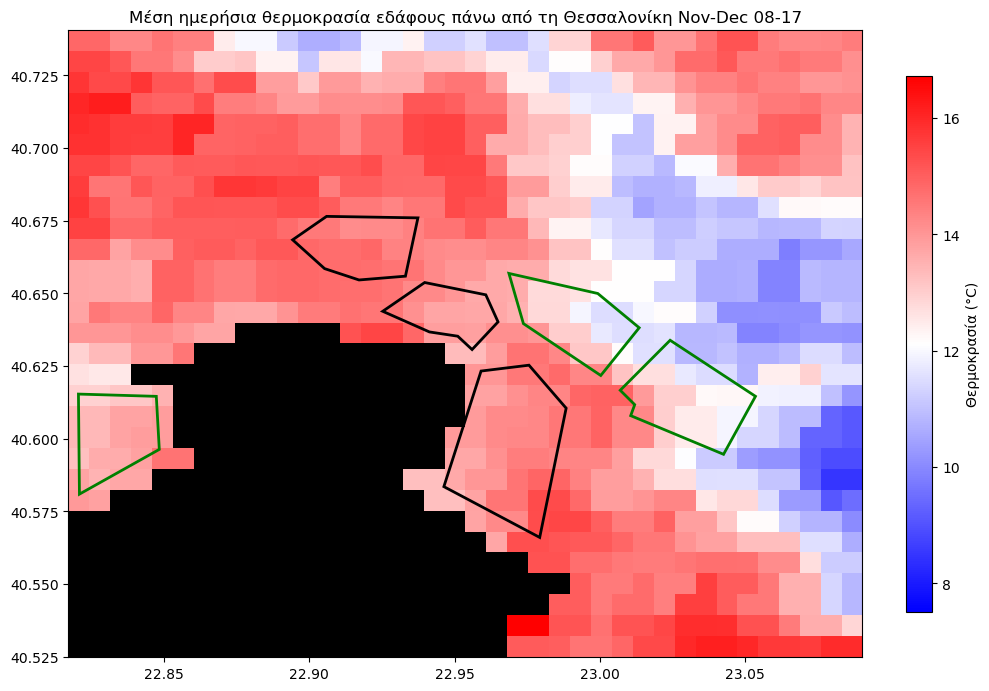

In [3]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from shapely.geometry import Polygon
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

# Path to the GeoTIFF file
tiff_path = r'C:\Users\HP\Desktop\Thess_Xan_Map\Day_LST_Thess_Winter_800.tif'

# Updated Urban Areas
urban_areas = [
    # Area 0
    [
        [22.956023316405574, 40.630636938304946],
        [22.964950239306457, 40.64014710656182],
        [22.960744870476464, 40.649460740490795],
        [22.939714923629733, 40.653693220998925],
        [22.925294918575865, 40.643794265853565],
        [22.94134727701008, 40.636695558255845],
        [22.951088888912707, 40.63522972493615],
        [22.956023316405574, 40.630636938304946]
    ],
    # Area 1
    [
        [22.90598007091484, 40.67644395345566],
        [22.894307097282027, 40.66837178433737],
        [22.905293425407027, 40.658475534230206],
        [22.917138060416793, 40.65456871552202],
        [22.933102568473434, 40.65587101384508],
        [22.93739410289726, 40.67592319784154],
        [22.90598007091484, 40.67644395345566]
    ],
    # Area 2
    [
        [22.959109267081832, 40.623240784062865],
        [22.946320494498824, 40.583489832147094],
        [22.979279478873824, 40.5660180052485],
        [22.98837753185234, 40.61047092473823],
        [22.975588759269332, 40.625260283151505],
        [22.959109267081832, 40.623240784062865]
    ]
]

# Updated Rural Areas
rural_areas = [
    # Area 0
    [
        [23.006974717428086, 40.616633380770324],
        [23.011952897359727, 40.61168160265654],
        [23.010579606344102, 40.607902367196075],
        [23.042508622457383, 40.59460818599018],
        [23.053494950582383, 40.61454846629424],
        [23.0241408551234, 40.63383144260097],
        [23.006974717428086, 40.616633380770324]
    ],
    # Area 1
    [
        [22.96869423036754, 40.656820415926234],
        [22.97367241029918, 40.6395631457412],
        [23.000279923726914, 40.621715087229234],
        [23.013497849752305, 40.63813026608933],
        [22.99925183602131, 40.64991901414545],
        [22.96869423036754, 40.656820415926234]
    ],
    # Area 2
    [
        [22.820637634816965, 40.615323549509675],
        [22.82098095757087, 40.58091346699633],
        [22.84844677788337, 40.596295920165815],
        [22.847416809621652, 40.61454169887752],
        [22.820637634816965, 40.615323549509675]
    ]
]

# Open the GeoTIFF file
with rasterio.open(tiff_path) as src:
    # Plot the GeoTIFF file
    fig, ax = plt.subplots(figsize=(10, 8))
    show(src, ax=ax)

    # Plot each rural area with green lines
    for area in rural_areas:
        polygon = Polygon(area)
        mpl_polygon = MplPolygon(list(polygon.exterior.coords), edgecolor='green', facecolor='none', linewidth=2)
        ax.add_patch(mpl_polygon)

    # Plot each urban area with black lines
    for urban in urban_areas:
        polygon = Polygon(urban)
        mpl_polygon = MplPolygon(list(polygon.exterior.coords), edgecolor='black', facecolor='none', linewidth=2)
        ax.add_patch(mpl_polygon)

    # Add a title
    plt.title('Μέση ημερήσια θερμοκρασία εδάφους πάνω από τη Θεσσαλονίκη Nov-Dec 08-17')

    # Define the minimum and maximum temperature
    min_temp = 7.508367347
    max_temp = 16.72384615

    # Define the colors for the colormap (red, white, blue)
    colors = [(0, 'blue'), (0.5, 'white'), (1, 'red')]

    # Create a custom colormap
    cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

    # Create a ScalarMappable object for the color bar
    sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=min_temp, vmax=max_temp))
    sm.set_array([])  # Dummy array for the ScalarMappable

    # Add the color bar to the plot
    fig.colorbar(sm, ax=ax, label='Θερμοκρασία (°C)', orientation='vertical', fraction=0.0310)

    # Adjust layout
    plt.tight_layout()
    plt.show()
